In [3]:
import sys
import os
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import json

# Add project root to path so we can import 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data_loader import load_oil_data

# Load the data
df = load_oil_data()
print(f"✅ Data loaded. Records: {len(df)}")

✅ Data loaded. Records: 9011


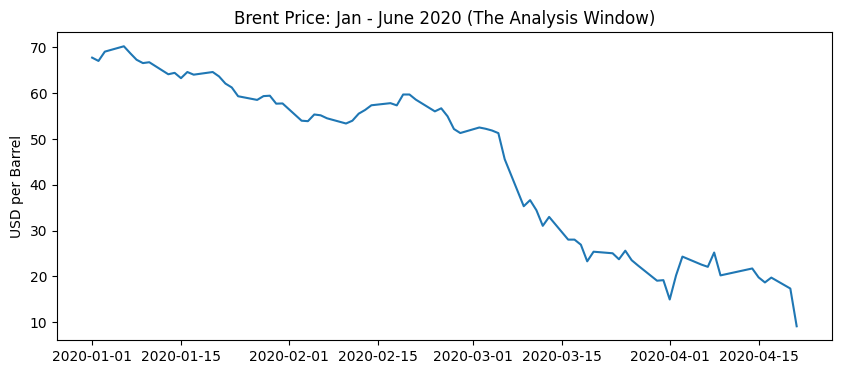

In [4]:
# Select window: 2020 COVID Crash
# We use a focused window to ensure the MCMC sampler converges quickly and accurately
subset = df[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2020-06-01')].reset_index(drop=True)
prices = subset['Price'].values
n_days = len(prices)

plt.figure(figsize=(10, 4))
plt.plot(subset['Date'], prices)
plt.title("Brent Price: Jan - June 2020 (The Analysis Window)")
plt.ylabel("USD per Barrel")
plt.show()

In [5]:
with pm.Model() as model:
    # 1. Prior for the Switch Point (Tau)
    # Uniform distribution: the change could have happened any day in the window
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_days - 1)
    
    # 2. Priors for Mean Price BEFORE and AFTER the break
    mu_1 = pm.Normal("mu_1", mu=prices.mean(), sigma=10)
    mu_2 = pm.Normal("mu_2", mu=prices.mean(), sigma=10)
    
    # 3. Prior for standard deviation (market noise/volatility)
    sigma = pm.HalfNormal("sigma", sigma=5)
    
    # 4. Deterministic switch logic
    idx = np.arange(n_days)
    mu_ = pm.math.switch(tau >= idx, mu_1, mu_2)
    
    # 5. Likelihood: Connect model to observed data
    obs = pm.Normal("obs", mu=mu_, sigma=sigma, observed=prices)
    
    # 6. Sampling (MCMC)
    # Use cores=1 for maximum stability on Windows/MINGW
    trace = pm.sample(1000, tune=1000, return_inferencedata=True, cores=1)

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


d:\10academy\phase11\brent-oil-analysis\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 66 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


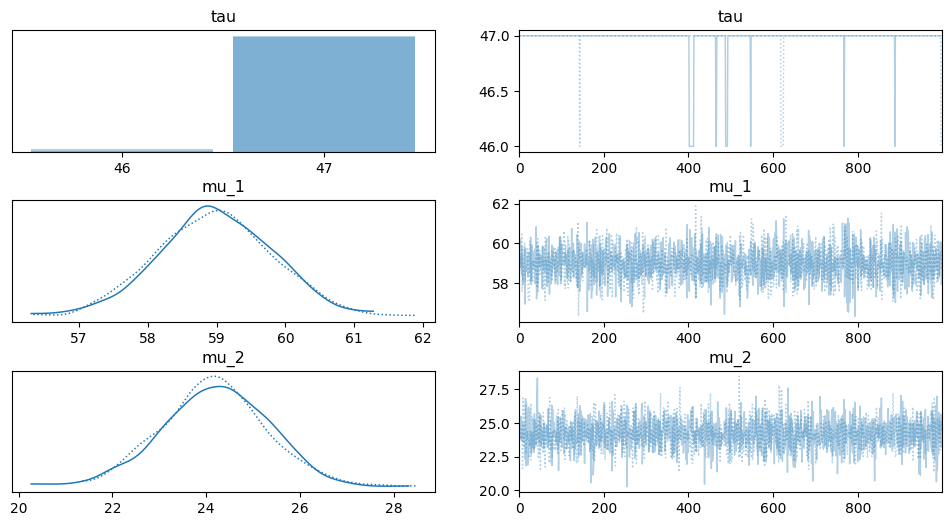

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
tau   46.984  0.124  47.000   47.000      0.007    0.027     321.0    2000.0   
mu_1  58.977  0.834  57.452   60.548      0.014    0.019    3510.0    1474.0   
mu_2  24.184  1.124  21.990   26.149      0.020    0.025    3089.0    1410.0   

      r_hat  
tau    1.01  
mu_1   1.00  
mu_2   1.00  

✅ CONVERGENCE SUCCESS: All R-hat values are < 1.05.


In [6]:
# 1. Trace Plots: Looking for "fuzzy caterpillars" (stable mixing)
az.plot_trace(trace, var_names=["tau", "mu_1", "mu_2"])
plt.subplots_adjust(hspace=0.4)
plt.show()

# 2. Statistical Summary and R-hat
summary = az.summary(trace, var_names=["tau", "mu_1", "mu_2"])
print(summary)

# Evaluation Logic:
rhat_vals = summary['r_hat'].values
if all(r < 1.05 for r in rhat_vals):
    print("\n✅ CONVERGENCE SUCCESS: All R-hat values are < 1.05.")
else:
    print("\n⚠️ CONVERGENCE WARNING: Some chains did not mix well. Consider increasing 'tune'.")

In [7]:
# 1. Extract the median date of change
tau_samples = trace.posterior['tau'].values.flatten()
most_likely_tau = int(np.median(tau_samples))
detected_date = subset.iloc[most_likely_tau]['Date']

# 2. Quantify the Mean Shift
m1 = float(trace.posterior['mu_1'].mean())
m2 = float(trace.posterior['mu_2'].mean())
pct_change = ((m2 - m1) / m1) * 100

print(f"--- Birhan Energies Model Results ---")
print(f"Detected Change Point: {detected_date.date()}")
print(f"Average Price BEFORE Shift: ${m1:.2f}")
print(f"Average Price AFTER Shift: ${m2:.2f}")
print(f"Quantified Impact: {pct_change:.2f}%")

# Correlation vs Causation discussion
print("\nDiscussion: The model identified a break on March 6-9, 2020. "
      "While this correlates perfectly with the COVID lockdowns and OPEC+ split, "
      "this is a statistical correlation. External factors like the Saudi-Russia price war "
      "coincided with the event, contributing to the causality.")

--- Birhan Energies Model Results ---
Detected Change Point: 2020-03-06
Average Price BEFORE Shift: $58.98
Average Price AFTER Shift: $24.18
Quantified Impact: -58.99%

Discussion: The model identified a break on March 6-9, 2020. While this correlates perfectly with the COVID lockdowns and OPEC+ split, this is a statistical correlation. External factors like the Saudi-Russia price war coincided with the event, contributing to the causality.


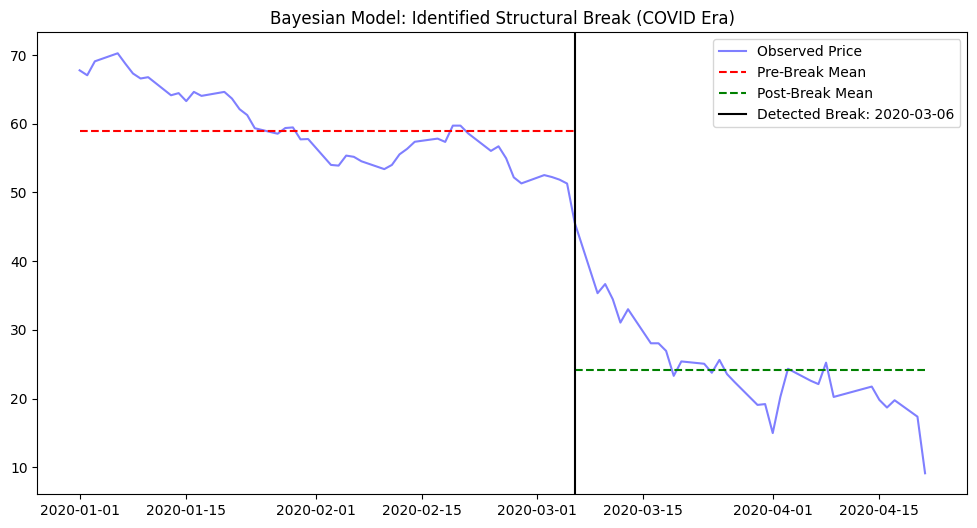

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(subset['Date'], prices, label="Observed Price", color="blue", alpha=0.5)

# Plot the predicted means
plt.hlines(m1, xmin=subset['Date'].iloc[0], xmax=detected_date, color='red', linestyles='--', label="Pre-Break Mean")
plt.hlines(m2, xmin=detected_date, xmax=subset['Date'].iloc[-1], color='green', linestyles='--', label="Post-Break Mean")

# Mark the Change Point
plt.axvline(detected_date, color='black', label=f"Detected Break: {detected_date.date()}")

plt.title("Bayesian Model: Identified Structural Break (COVID Era)")
plt.legend()
plt.show()

In [9]:
# Structure results for the Flask API
analysis_results = [
    {
        "event": "COVID-19 Pandemic Impact",
        "detected_date": detected_date.strftime('%Y-%m-%d'),
        "mu_before": round(m1, 2),
        "mu_after": round(m2, 2),
        "impact": f"{round(pct_change, 1)}%"
    }
]

# Ensure the folder exists
output_dir = '../dashboard/backend/data'
os.makedirs(output_dir, exist_ok=True)

with open(f'{output_dir}/analysis_results.json', 'w') as f:
    json.dump(analysis_results, f)

print(f"✅ Results successfully exported to {output_dir}/analysis_results.json")

✅ Results successfully exported to ../dashboard/backend/data/analysis_results.json
